# Venue Effect 
— Treated vs. Control Trajectory PlotsThis notebook reproduces the matched-trajectory plots from `plot_matched.py`.  
It is designed so you can **import the core functions** from a separate module,or run everything interactively cell-by-cell.---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_rows', 100)
# ── Plotting defaults ──────────────────────────────────────────
plt.rcParams.update({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'ytick.left':         False,
    'axes.grid':          True,
    'axes.grid.which':    'major',
    'axes.grid.axis':     'y',
    'grid.linestyle':     '--',
    'grid.alpha':         0.3,
})


## 1 · Data loading

In [2]:
def load_merged(path: str | Path) -> pd.DataFrame:
    """Load a semicolon-separated matched CSV produced by the pipeline."""
    df = pd.read_csv(path, sep=';')
    print(f'Loaded {path}: {len(df):,} rows, {df["author_id"].nunique()} authors')
    return df


In [3]:
def split_treated_control(df: pd.DataFrame):
    """Return (treated_ids, control_ids) as sets of author_id."""
    if 'matched_to' in df.columns:
        treated_ids = set(df[df['matched_to'].isna()]['author_id'].unique())
        control_ids = set(df[df['matched_to'].notna()]['author_id'].unique())
    else:
        treated_ids = set(df[df['is_venue'] == 1]['author_id'].unique())
        control_ids = set(df['author_id'].unique()) - treated_ids
    return treated_ids, control_ids


## 2 · Statistics helper

In [4]:
def compute_stats(df: pd.DataFrame, col: str, author_ids: set) -> pd.DataFrame:
    """
    For a given metric column and author subset, compute per-to_year:
      mean, standard error, 95 % CI bounds, and sample size.
    """
    sub = df[df['author_id'].isin(author_ids)].copy()
    sub[col] = pd.to_numeric(sub[col], errors='coerce')

    rows = []
    for ty in sorted(sub['to_year'].unique()):
        vals = sub.loc[sub['to_year'] == ty, col].dropna()
        n = len(vals)
        if n == 0:
            rows.append({'to_year': ty, 'mean': np.nan, 'se': 0, 'n': 0})
            continue
        m  = vals.mean()
        se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
        rows.append({'to_year': ty, 'mean': m, 'se': se, 'n': n})

    out = pd.DataFrame(rows)
    out['ci_lo'] = out['mean'] - 1.96 * out['se']
    out['ci_hi'] = out['mean'] + 1.96 * out['se']
    return out


## 3 · Single-metric plot

In [5]:
def plot_one(t_stats, c_stats, ylabel, out_path=None):
    """
    Draw treated vs control trajectories with 95 % CI error bars.

    Parameters
    ----------
    t_stats, c_stats : pd.DataFrame
        Output of `compute_stats` for treated / control groups.
    ylabel : str
        Label for the y-axis.
    out_path : str | Path | None
        If given, save the figure there (600 dpi) and close it.
    """
    # Fixed axes size: 2 × 2 inches
    ax_w, ax_h = 2, 2
    left_margin, bottom_margin = 0.75, 0.55
    right_margin, top_margin   = 0.15, 0.15

    fw = left_margin + ax_w + right_margin
    fh = bottom_margin + ax_h + top_margin
    fig = plt.figure(figsize=(fw, fh), dpi=600)  # 150 for notebook display
    fig.patch.set_alpha(0)   # whole figure transparent
    ax  = fig.add_axes([left_margin / fw, bottom_margin / fh,
                        ax_w / fw,        ax_h / fh])
    ax.patch.set_alpha(0)    # plotting area transparent
    # ── Control (behind) ──
    ax.errorbar(c_stats['to_year'], c_stats['mean'],
                yerr=1.96 * c_stats['se'],
                color='darkgray', fmt='none',
                capsize=3, capthick=0.96, elinewidth=0.96)
    ax.plot(c_stats['to_year'], c_stats['mean'],
            '-o', color='darkgray', markersize=4, linewidth=2,
            alpha=0.5, label='Control individuals')

    # ── Treated (on top) ──
    ax.errorbar(t_stats['to_year'], t_stats['mean'],
                yerr=1.96 * t_stats['se'],
                color='yellowgreen', fmt='none',
                capsize=3, capthick=0.96, elinewidth=0.96)
    ax.plot(t_stats['to_year'], t_stats['mean'],
            '-o', color='yellowgreen', markersize=4, linewidth=2,
            alpha=0.5, label='Venue access individuals')

    ax.axvline(x=0, color='grey', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Time to publish')
    ax.set_ylabel(ylabel)
    ax.set_xlim(-5.5, 10.5)

    if out_path:
        fig.savefig(out_path, dpi=600, transparent=True)
        plt.close(fig)
        print(f'  Saved → {out_path}')
    else:
        plt.show()


## 4 · Run all metricsSet `DATA_PATH` below with normalized count

In [31]:
# ── EDIT THIS PATH ──────────────────────────────────────────────
DATA_PATH  = '../../data/matches/enriched_novelty/merged_physics_PNAS_enriched_novelty.csv'
SAVE_FIGS  = True       # set True to write PNGs
OUTPUT_DIR = '../../figure'
# ────────────────────────────────────────────────────────────────

METRICS = [
    ('cum_citations_na',         '# Citations'),
    ('cum_publication_count_adj', '# Productivity'),
    ('cum_funding_count',         '# Grants'),
    # ('cum_normalized_citations',             '# Normalized Citations'),
    # ('cum_citations_old',         '# Pre-venue work citations'),
    # ('pct_novel',         'Novelty'),
    
]

# METRICS = [
#     ('cum_normalized_citations',             '# Normalized Citations'),
#     ('cum_normalized_productivity', '# Normalized Productivity'),
#     ('cum_normalized_funding_count',         '# Normalized Grants'),
# ]

df = load_merged(DATA_PATH)

Loaded ../../data/matches/enriched_novelty/merged_physics_PNAS_enriched_novelty.csv: 7,488 rows, 455 authors


In [38]:
# ── EDIT THIS PATH ──────────────────────────────────────────────
DATA_PATH  = '../../data/matches/enriched_l2/merged_physics_Nature_enriched_l2.csv'
SAVE_FIGS  = False        # set True to write PNGs
OUTPUT_DIR = '../../figure'
# ────────────────────────────────────────────────────────────────

METRICS = [
    ('cum_citations_na',         '# Citations'),
    ('cum_publication_count_adj', '# Productivity'),
    ('cum_funding_count',         '# Grants'),
    ('cum_citations_old',         '# Pre-venue work citations'),]

df = load_merged(DATA_PATH)

Loaded ../../data/matches/enriched_l2/merged_physics_Nature_enriched_l2.csv: 103,840 rows, 5924 authors


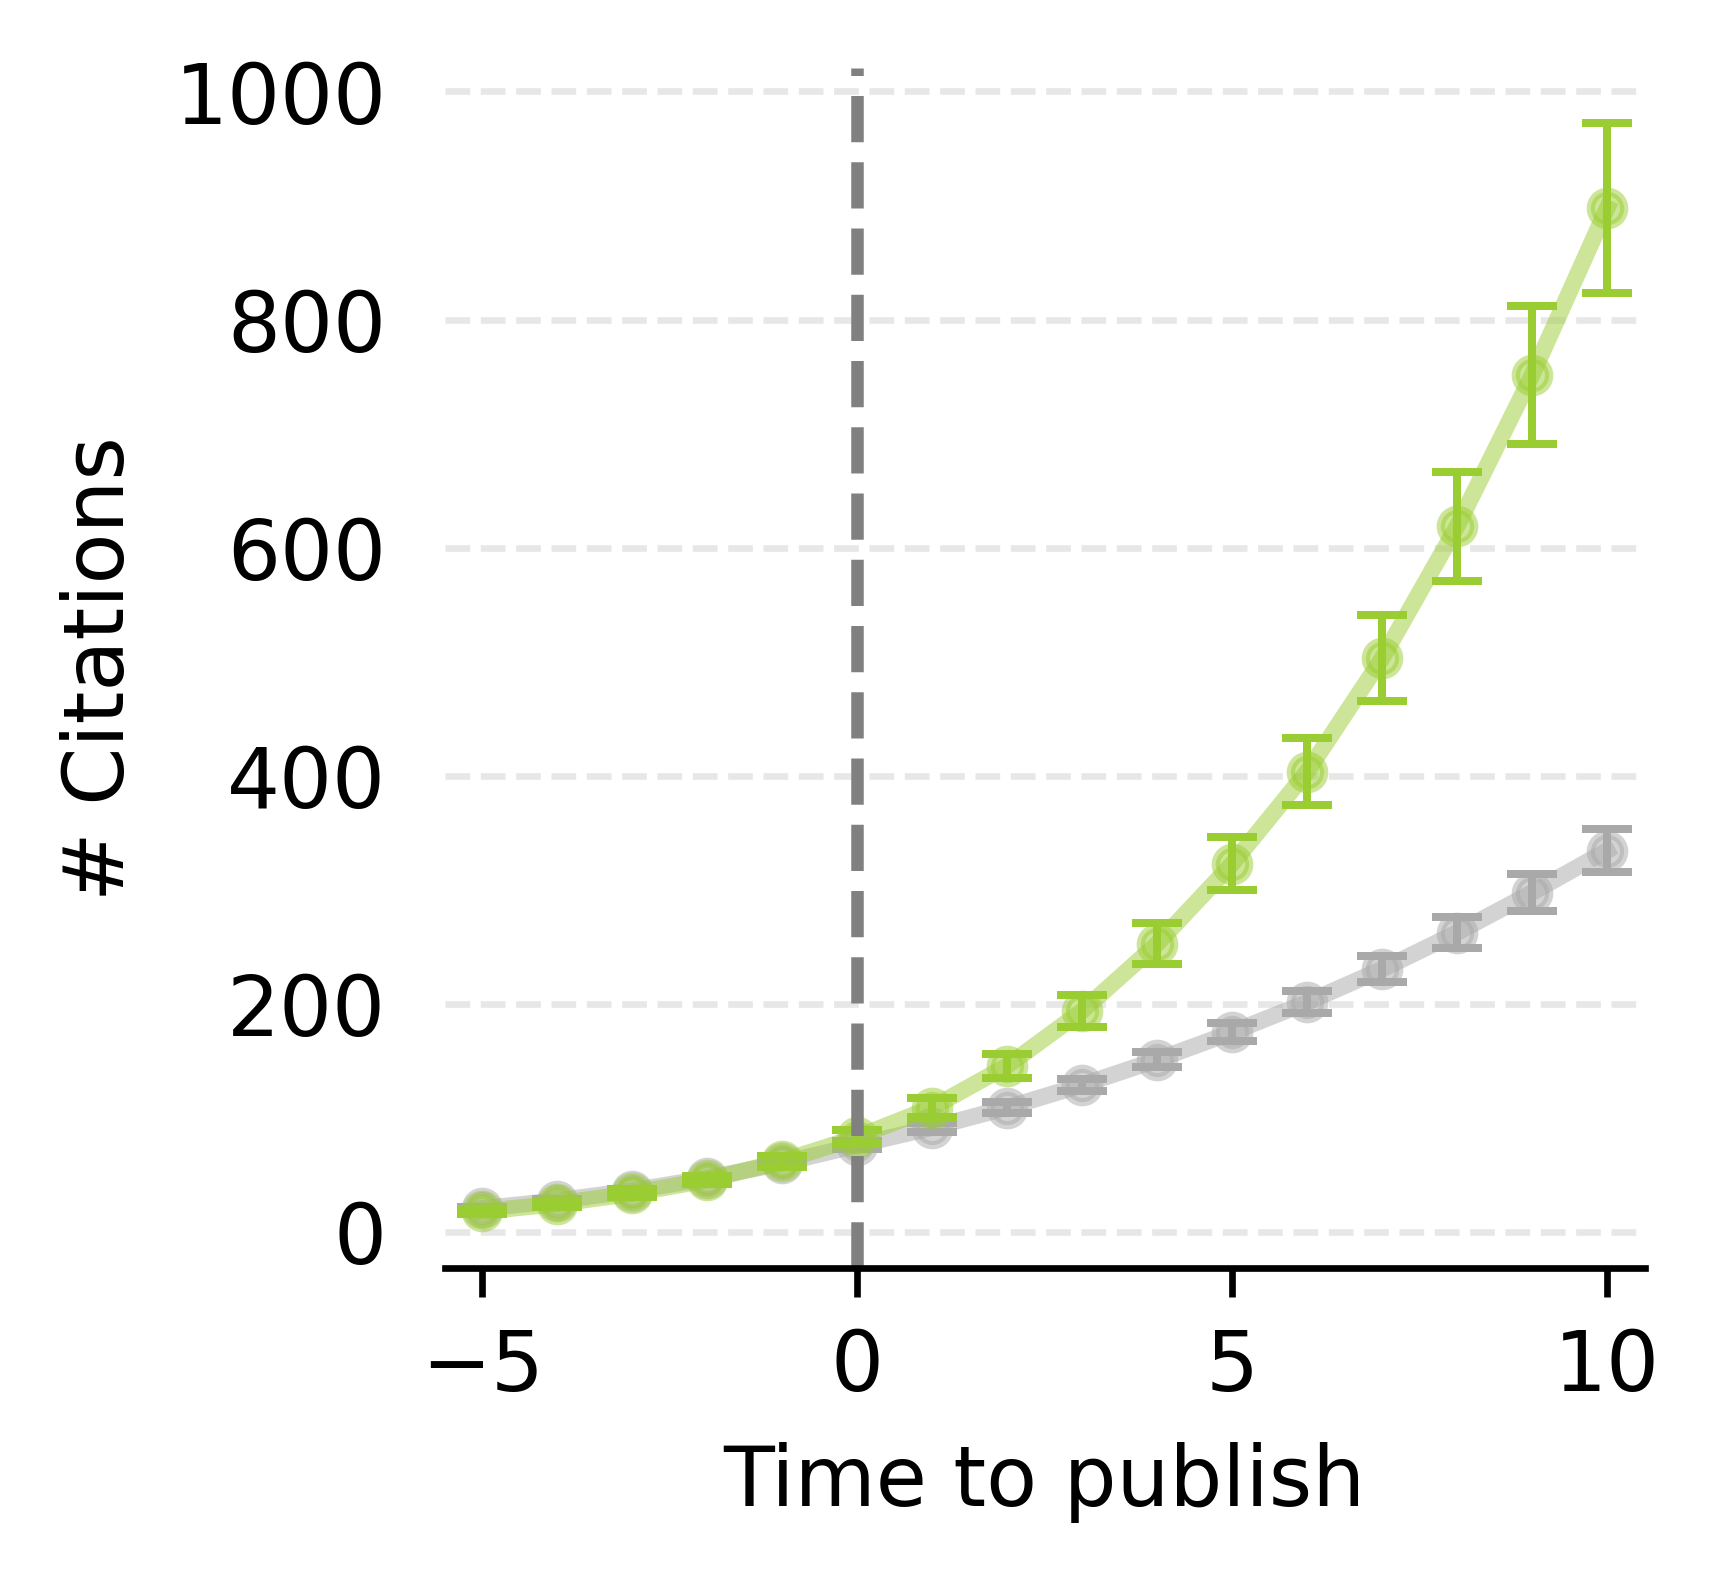

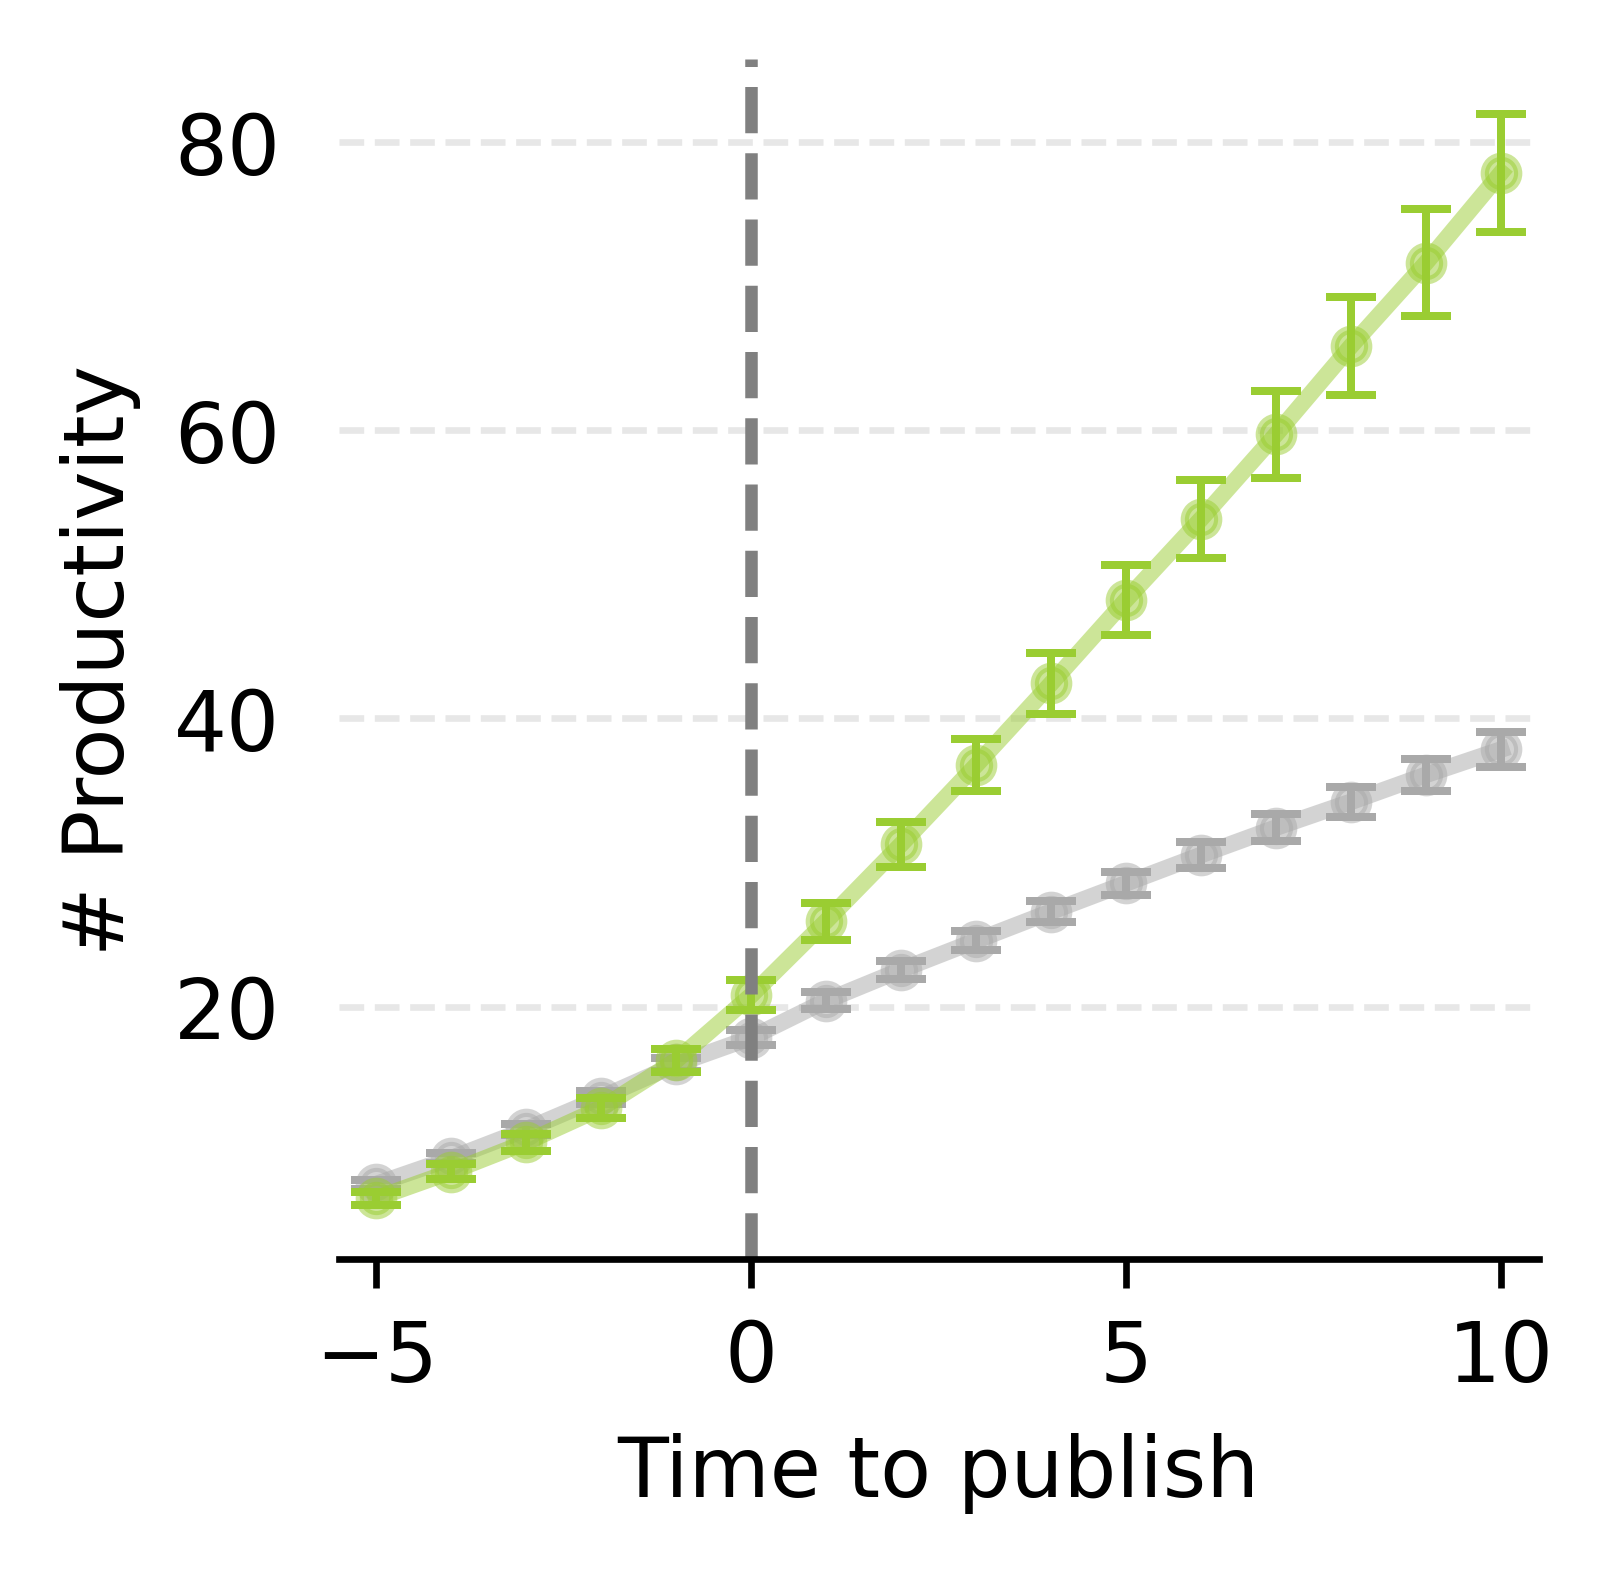

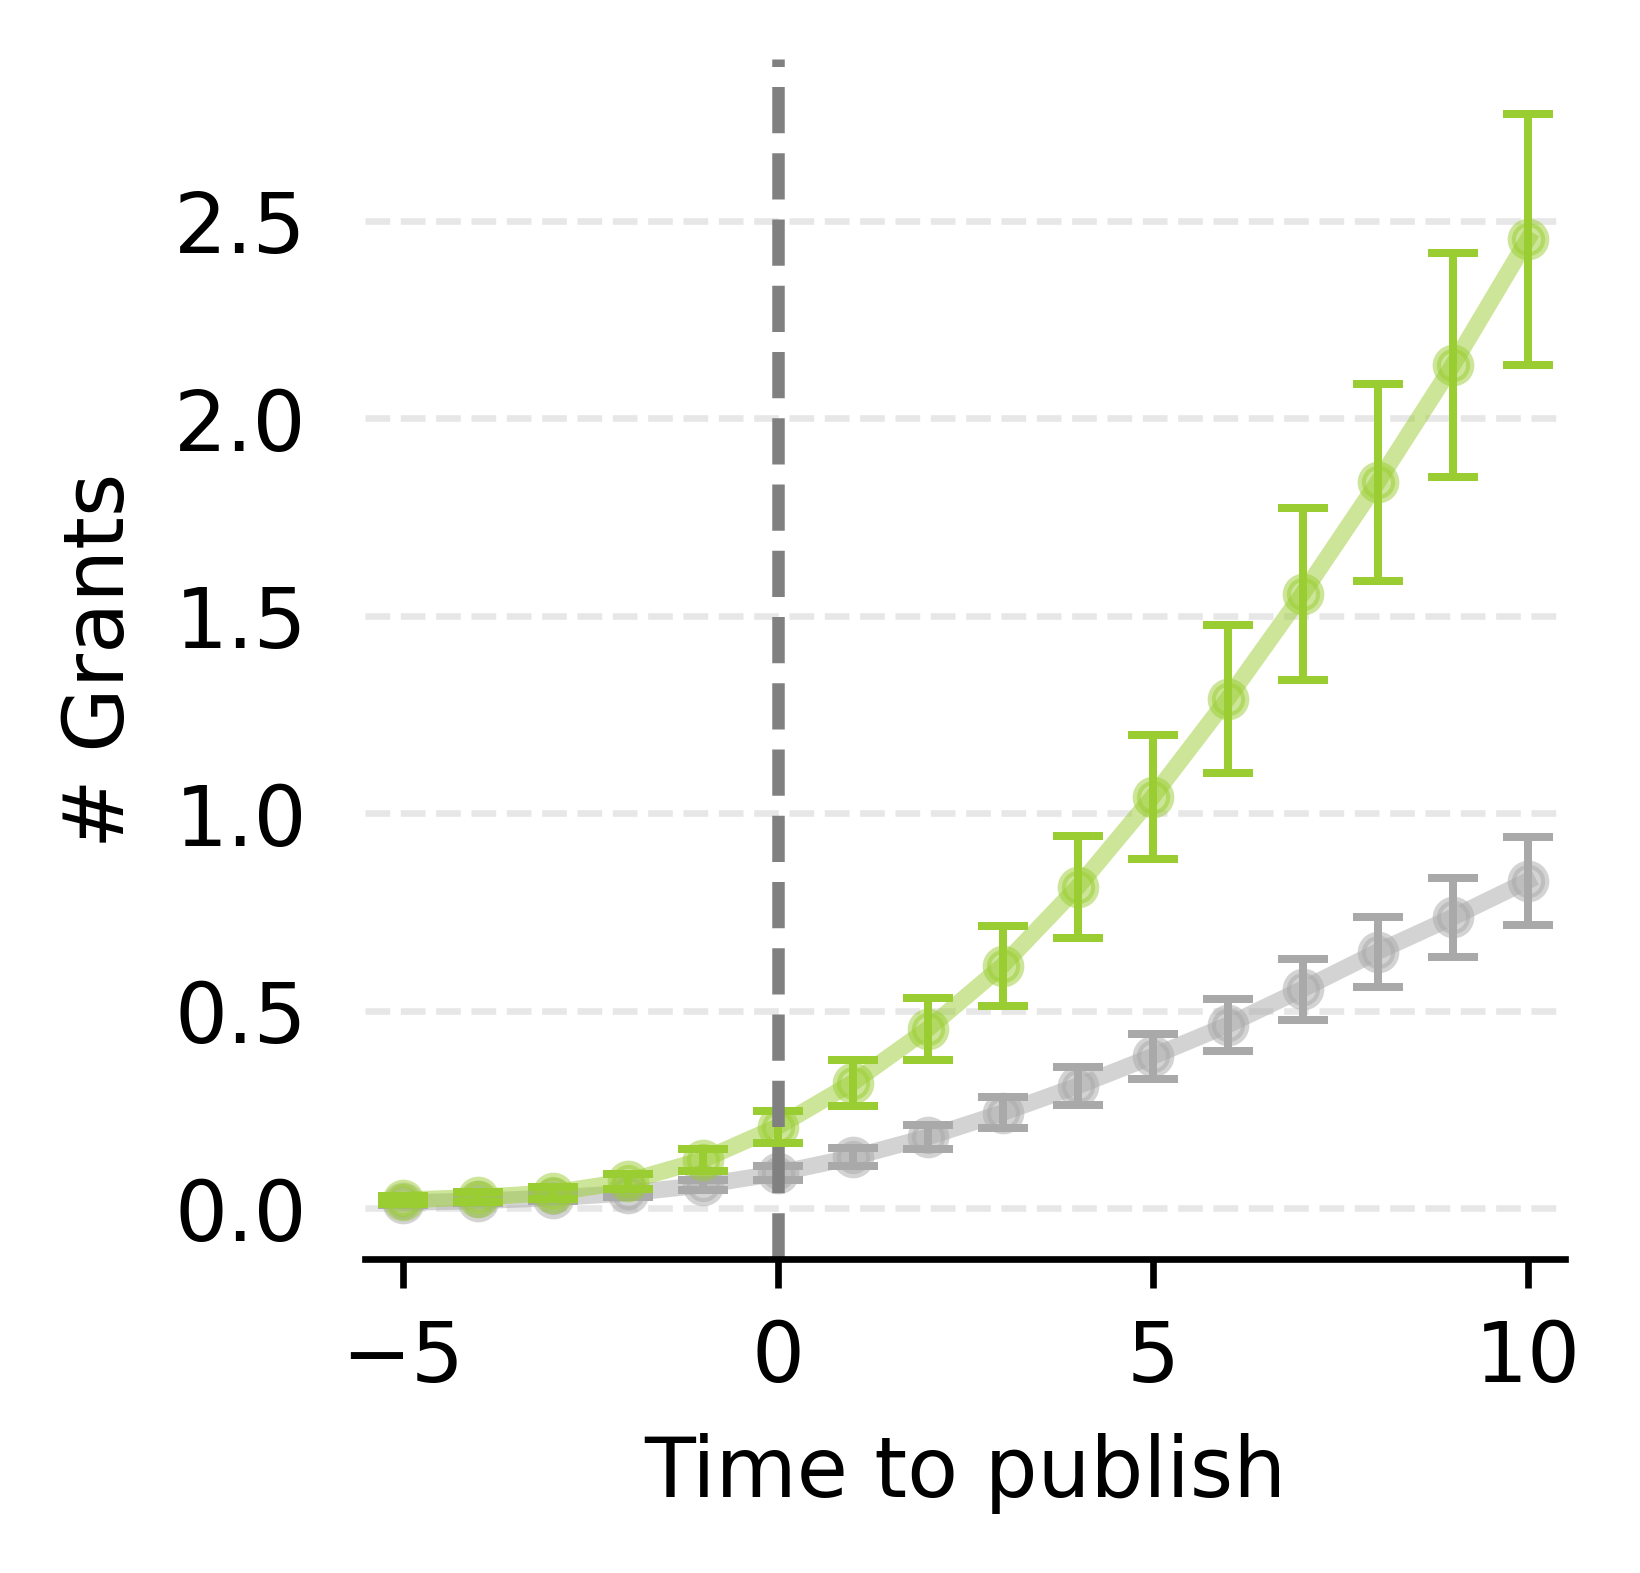

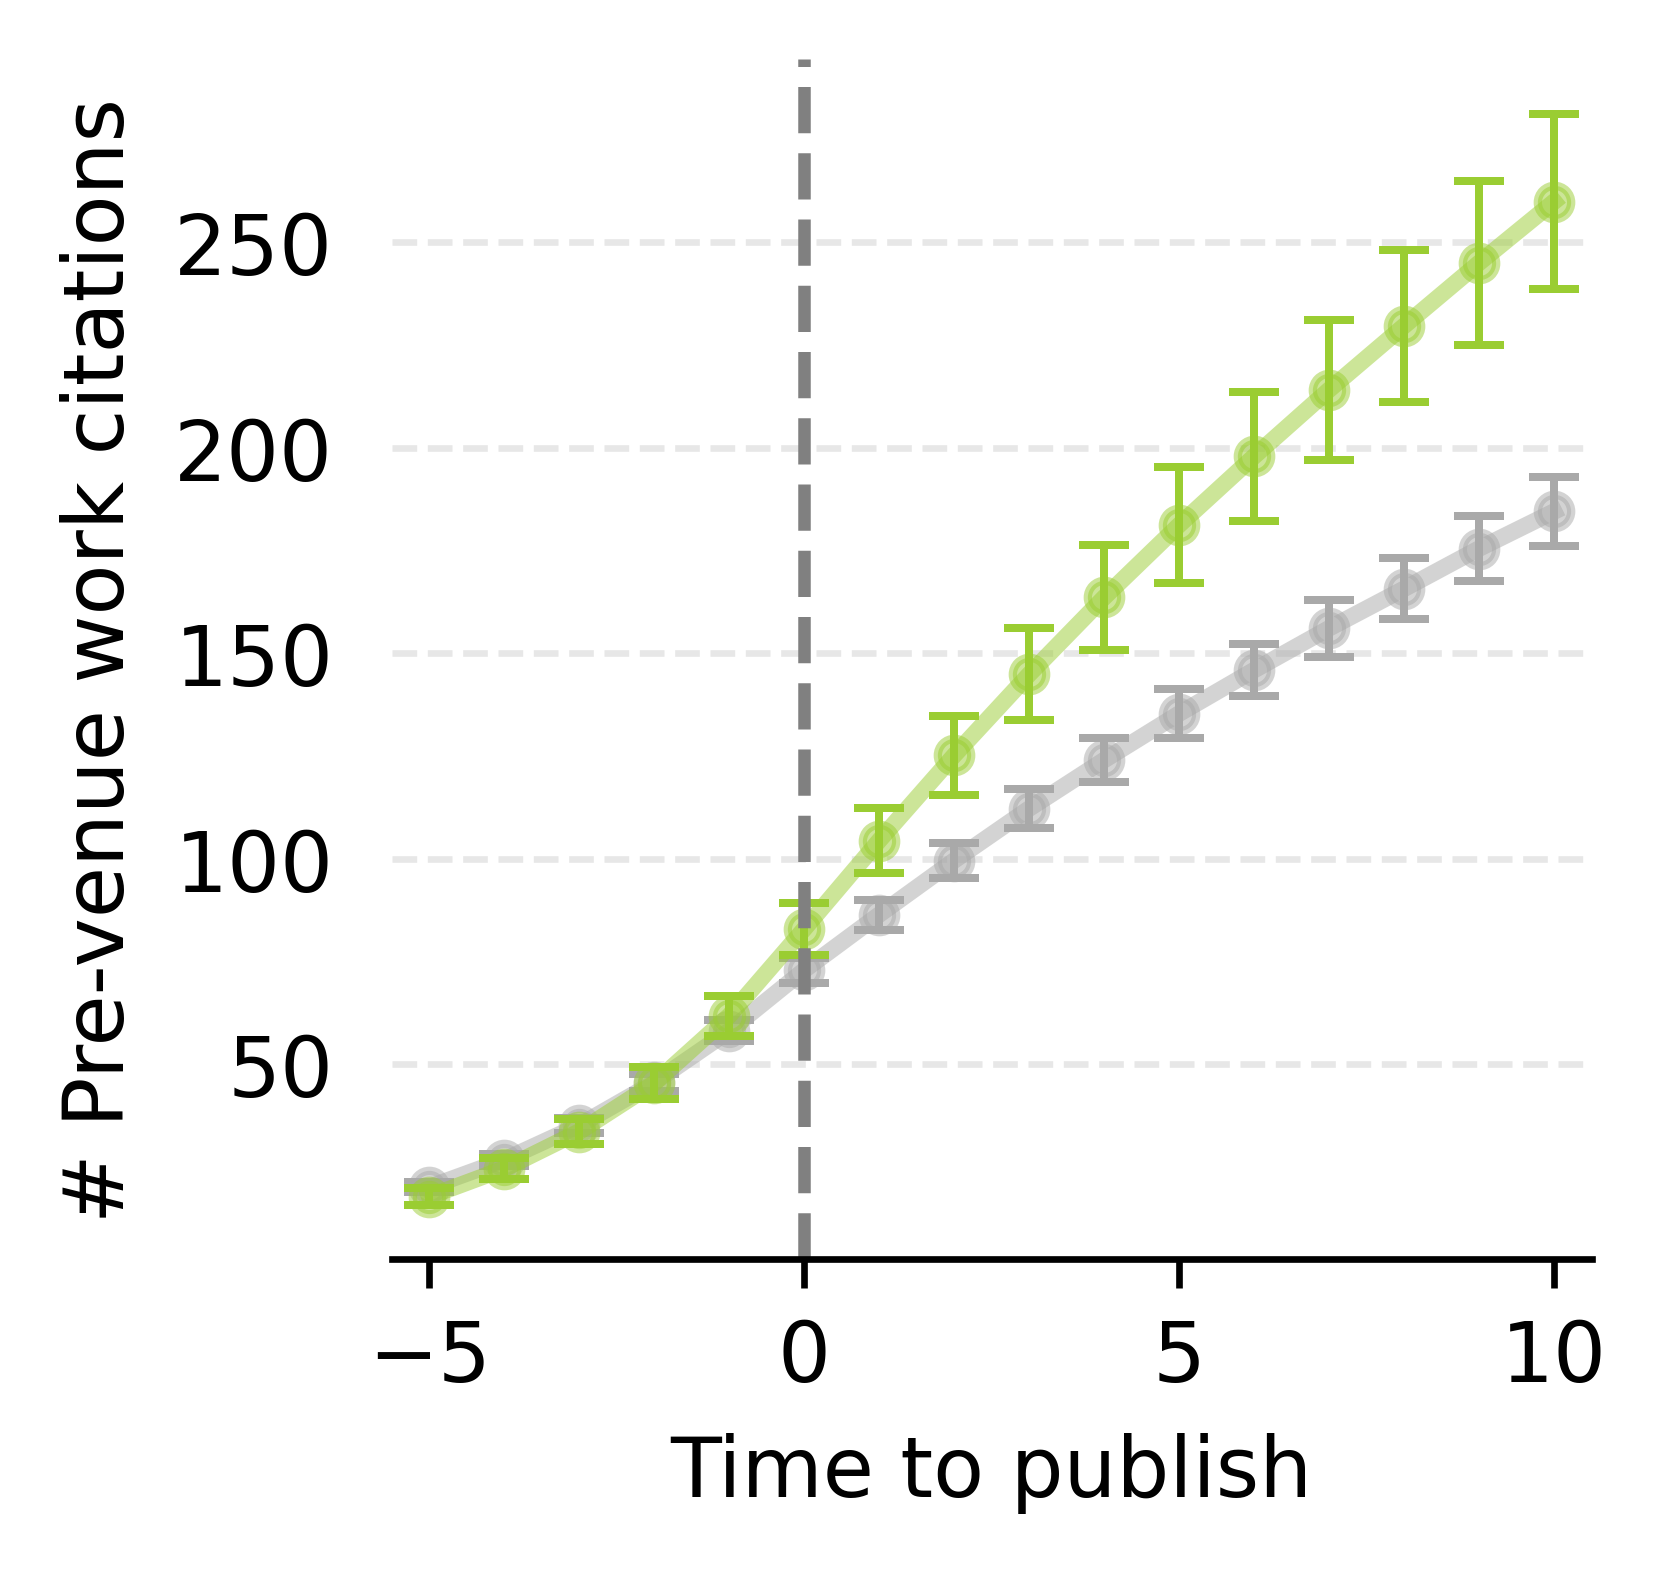


Log table: 128 rows


,file,metric,group,to_year,mean,ci_lo,ci_hi,n
0,physics_Nature_enriched_l2,cum_citations_na,treated,-5,17.865973,15.858053,19.873893,1634
1,physics_Nature_enriched_l2,cum_citations_na,treated,-4,24.641983,22.149315,27.134650,1634
2,physics_Nature_enriched_l2,cum_citations_na,treated,-3,33.662791,30.568576,36.757005,1634
3,physics_Nature_enriched_l2,cum_citations_na,treated,-2,45.468788,41.618477,49.319099,1634
4,physics_Nature_enriched_l2,cum_citations_na,treated,-1,61.924113,57.010046,66.838179,1634
5,physics_Nature_enriched_l2,cum_citations_na,treated,0,83.084455,76.746870,89.422041,1634
6,physics_Nature_enriched_l2,cum_citations_na,treated,1,109.038556,100.889180,117.187932,1634
7,physics_Nature_enriched_l2,cum_citations_na,treated,2,145.616891,134.990289,156.243493,1634
8,physics_Nature_enriched_l2,cum_citations_na,treated,3,193.725826,179.840921,207.610732,1634
9,physics_Nature_enriched_l2,cum_citations_na,treated,4,252.635863,234.648176,270.623550,1634


In [39]:

treated_ids, control_ids = split_treated_control(df)

stem  = Path(DATA_PATH).stem
label = stem.replace('merged_', '')

out_dir = Path(OUTPUT_DIR)
if SAVE_FIGS:
    out_dir.mkdir(parents=True, exist_ok=True)

log_rows = []

for col, ylabel in METRICS:
    if col not in df.columns:
        print(f'  ⚠ {col} not found — skipping')
        continue

    t_stats = compute_stats(df, col, treated_ids)
    c_stats = compute_stats(df, col, control_ids)

    safe_col = col.replace('cum_', '')
    out_path = out_dir / f'{label}_{safe_col}.png' if SAVE_FIGS else None
    plot_one(t_stats, c_stats, ylabel, out_path)

    # accumulate log
    for _, r in t_stats.iterrows():
        log_rows.append({
            'file': label, 'metric': col, 'group': 'treated',
            'to_year': int(r['to_year']), 'mean': r['mean'],
            'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'], 'n': int(r['n']),
        })
    for _, r in c_stats.iterrows():
        log_rows.append({
            'file': label, 'metric': col, 'group': 'control',
            'to_year': int(r['to_year']), 'mean': r['mean'],
            'ci_lo': r['ci_lo'], 'ci_hi': r['ci_hi'], 'n': int(r['n']),
        })

log_df = pd.DataFrame(log_rows)
print(f'\nLog table: {len(log_df)} rows')
log_df.head(96)


# 6 · Decade cohort plots by venue



-- Nature --


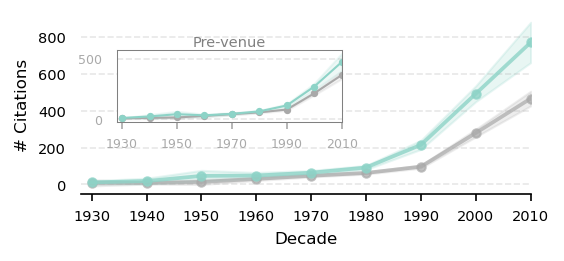

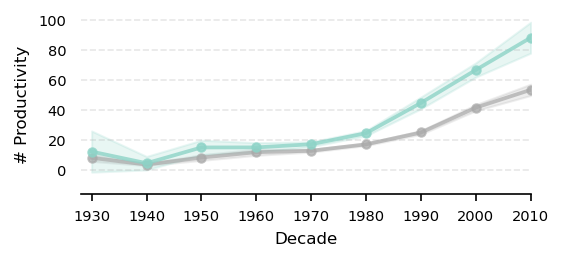


-- Science --


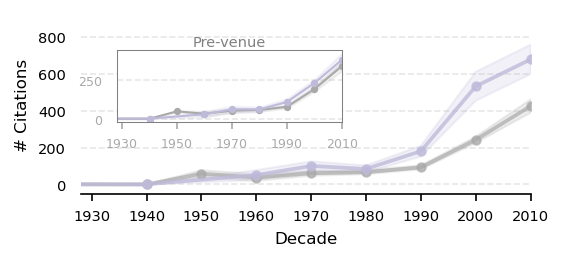

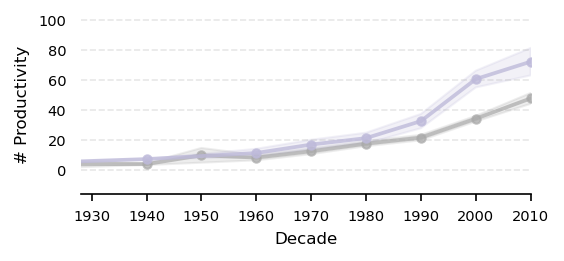


-- PNAS --


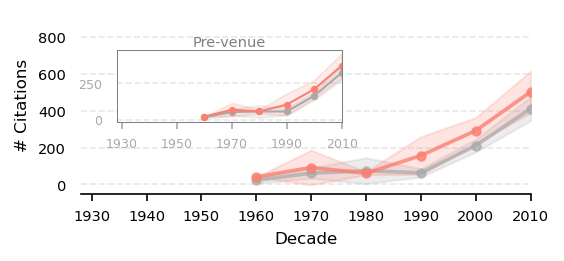

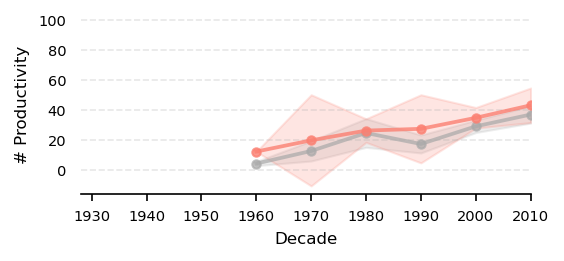


-- PRL --


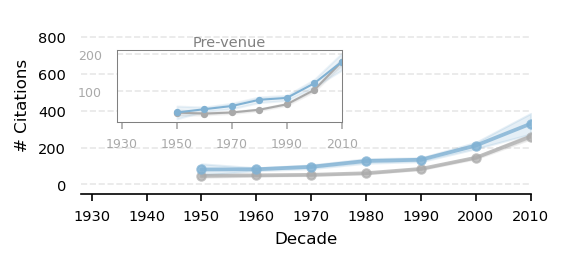

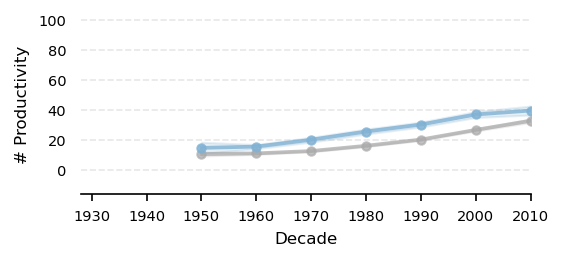


-- PRA --


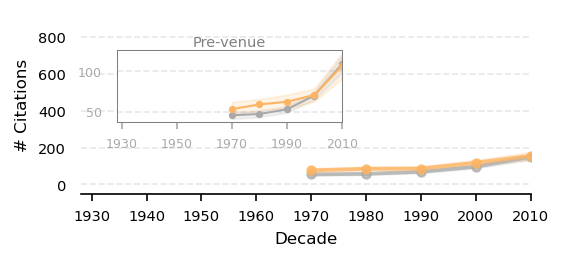

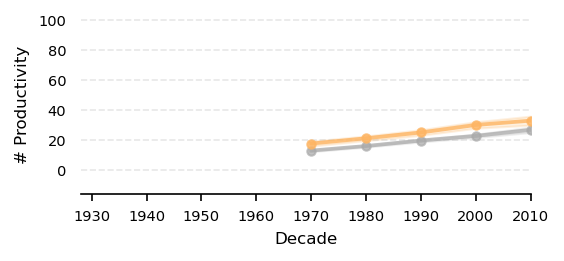


-- PRB --


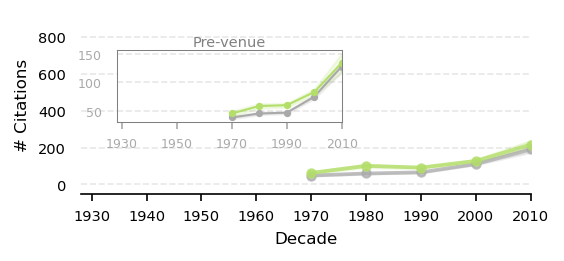

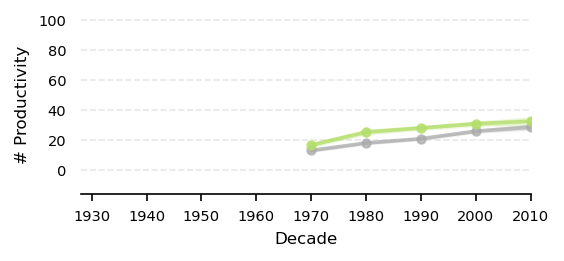


-- PRC --


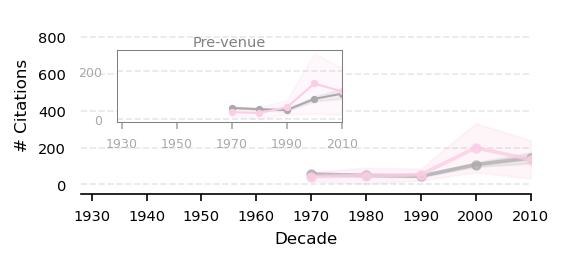

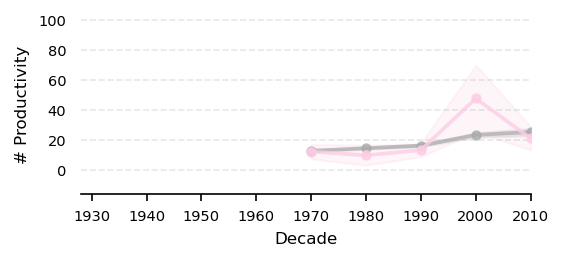


-- PRD --


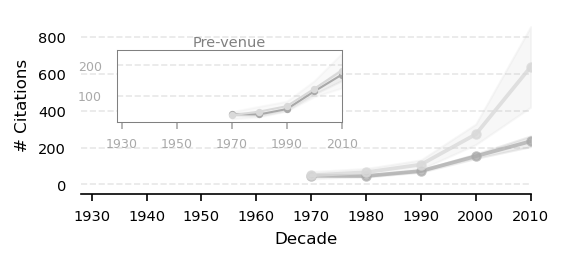

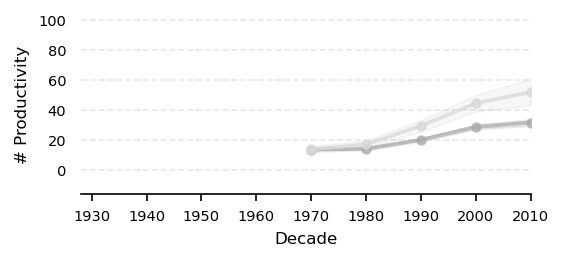


-- PRE --


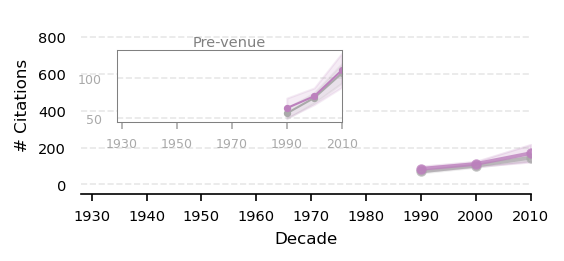

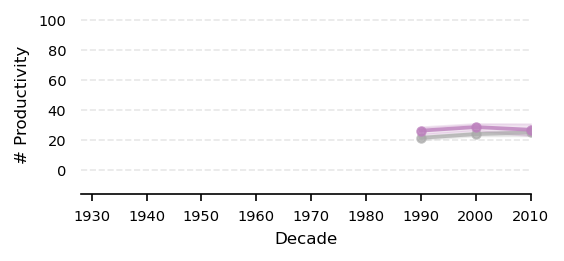

In [35]:
# %% [markdown]
# ## 6 · Decade cohort plots (x = decade, y = 5-yr post-venue outcome)
# Main plots:
#   - cum_citations_na
#   - cum_publication_count_adj
# Inset inside citations plot:
#   - cum_citations_old

# %%
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.left'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['ytick.left'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['axes.grid.which'] = 'major'
plt.rcParams['axes.grid.axis'] = 'y'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.3

# ── Venue list & Set2 palette ──────────────────────────────────
VENUES = [
    ('Nature',  'merged_physics_Nature_enriched_l2.csv'),
    ('Science', 'merged_physics_Science_enriched_l2.csv'),
    ('PNAS',    'merged_physics_PNAS_enriched_l2.csv'),
    ('PRL',     'merged_physics_PRL_enriched_l2.csv'),
    ('PRA',     'merged_physics_PRA_enriched_l2.csv'),
    ('PRB',     'merged_physics_PRB_enriched_l2.csv'),
    ('PRC',     'merged_physics_PRC_enriched_l2.csv'),
    ('PRD',     'merged_physics_PRD_enriched_l2.csv'),
    ('PRE',     'merged_physics_PRE_enriched_l2.csv'),
]

# SET2 = plt.cm.Set3.colors
SET2 = [c for i, c in enumerate(plt.cm.Set3.colors) if i != 1]
VENUE_COLORS = {v: SET2[i % len(SET2)] for i, (v, _) in enumerate(VENUES)}

DATA_DIR   = Path('../../data/matches/enriched_l2')
OUTPUT_DIR = Path('../../figure/decade')
SAVE_FIGS  = False

MAIN_METRICS = [
    ('cum_citations_na', '# Citations'),
    ('cum_publication_count_adj', '# Productivity')
]

INSET_OUTCOME = 'cum_citations_old'
INSET_LABEL = 'Pre-venue'

POST_YEAR = 5

hep_broad_fields = [
    'Particle and High Energy Physics',
    'Synchrotrons and Accelerators',
    'Nuclear and Plasma Physics'
]


# %%
def get_5yr_stats_by_decade(df, col, author_ids):
    """For each decade, get mean +/- 95% CI of `col` at to_year == POST_YEAR."""
    sub = df[(df['author_id'].isin(author_ids)) & (df['to_year'] == POST_YEAR)].copy()
    sub = sub[sub['venue_year'] >= 1900].copy()
    sub[col] = pd.to_numeric(sub[col], errors='coerce')
    sub = sub.dropna(subset=[col, 'venue_year'])
    sub['decade'] = (sub['venue_year'] // 10 * 10).astype(int)
    sub['decade'] >=1930

    rows = []
    for dec, grp in sub.groupby('decade'):
        vals = grp[col].dropna()
        n = len(vals)
        if n == 0:
            continue
        m = vals.mean()
        se = vals.std(ddof=1) / np.sqrt(n) if n > 1 else 0
        rows.append({
            'decade': dec,
            'mean': m,
            'se': se,
            'n': n,
            'ci_lo': m - 1.96 * se,
            'ci_hi': m + 1.96 * se
        })
    return pd.DataFrame(rows).sort_values('decade').reset_index(drop=True)


def plot_decade_curve_inset(ax_inset, t_dec, c_dec, color,
                            alpha_fill=0.15, alpha_line=1,
                            markersize=2.5, linewidth=1.0):
    """Smaller decade plot for inset."""
    if not c_dec.empty:
        ax_inset.fill_between(
            c_dec['decade'], c_dec['ci_lo'], c_dec['ci_hi'],
            color='darkgray', alpha=alpha_fill
        )
        ax_inset.plot(
            c_dec['decade'], c_dec['mean'],
            '-o', color='darkgray', linewidth=linewidth,
            alpha=alpha_line, markersize=markersize
        )

    if not t_dec.empty:
        ax_inset.fill_between(
            t_dec['decade'], t_dec['ci_lo'], t_dec['ci_hi'],
            color=color, alpha=alpha_fill
        )
        ax_inset.plot(
            t_dec['decade'], t_dec['mean'],
            '-o', color=color, linewidth=linewidth,
            alpha=alpha_line, markersize=markersize
        )

    ax_inset.tick_params(axis='both', labelsize=6, colors='darkgray')
    ax_inset.set_title(INSET_LABEL, fontsize=7, pad=2, color='gray')

    for spine in ax_inset.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
        spine.set_color('gray')


def plot_decade_curve(t_dec, c_dec, ylabel, color, title=None, out_path=None,
                      y_lim=None, x_ticks=None, x_lim=None,
                      inset_t_dec=None, inset_c_dec=None,
                      inset_bounds=[0.08, 0.40, 0.5, 0.4]):
    ax_w, ax_h = 3, 1.2
    lm, bm, rm, tm = 0.85, 0.55, 0.15, 0.30
    fw, fh = lm + ax_w + rm, bm + ax_h + tm
    fig = plt.figure(figsize=(fw, fh), dpi=150)
    ax = fig.add_axes([lm/fw, bm/fh, ax_w/fw, ax_h/fh])

    # control
    if not c_dec.empty:
        ax.fill_between(c_dec['decade'], c_dec['ci_lo'], c_dec['ci_hi'],
                        color='darkgray', alpha=0.2)
        ax.plot(c_dec['decade'], c_dec['mean'],
                '-o', color='darkgray', linewidth=1.8, alpha=0.7,
                markersize=4, label='Control')

    # treated
    if not t_dec.empty:
        ax.fill_between(t_dec['decade'], t_dec['ci_lo'], t_dec['ci_hi'],
                        color=color, alpha=0.2)
        ax.plot(t_dec['decade'], t_dec['mean'],
                '-o', color=color, markersize=4, linewidth=1.8, alpha=0.8,
                label='Treated')

    ax.set_xlabel('Decade', fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.tick_params(labelsize=7)

    if x_ticks is not None:
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f'{d}' for d in x_ticks])

    if x_lim is not None:
        ax.set_xlim(x_lim)

    if y_lim is not None:
        ax.set_ylim(y_lim)

    if title:
        ax.set_title(title, fontsize=9, pad=4)

    # inset only for citations plot
    if inset_t_dec is not None and inset_c_dec is not None:
        if (not inset_t_dec.empty) or (not inset_c_dec.empty):
            ax_ins = ax.inset_axes(inset_bounds)
            plot_decade_curve_inset(ax_ins, inset_t_dec, inset_c_dec, color=color)

            if x_ticks is not None:
                inset_ticks = x_ticks[::2] if len(x_ticks) > 6 else x_ticks
                ax_ins.set_xticks(inset_ticks)
                ax_ins.set_xticklabels([f'{d}' for d in inset_ticks])

            if x_lim is not None:
                ax_ins.set_xlim(x_lim)

    if out_path:
        out_path = Path(out_path)
    
        fig.savefig(out_path, dpi=600, bbox_inches='tight', transparent=True)
        print(f'  Saved -> {out_path}')
    
        pdf_path = out_path.with_suffix('.pdf')
        fig.savefig(pdf_path, bbox_inches='tight', transparent=True)
        print(f'  Saved -> {pdf_path}')
    
        plt.close(fig)
    else:
        plt.show()

# =========================================================
# Pass 1: load all data and compute stats first
# =========================================================
venue_results = {}
metric_ylims = {}
metric_xticks = {}

for vname, vfile in VENUES:
    fpath = DATA_DIR / vfile
    if not fpath.exists():
        print(f'Warning: {fpath} not found -- skipping')
        continue

    df = pd.read_csv(fpath, sep=';')

    # exclude HEP-like modal L2 fields; keep missing L2 labels
    if 'l2_field_modal_name' in df.columns:
        df = df[
            df['l2_field_modal_name'].isna() |
            (~df['l2_field_modal_name'].isin(hep_broad_fields))
        ].copy()

    color = VENUE_COLORS[vname]

    if 'matched_to' in df.columns:
        treated_ids = set(df[df['matched_to'].isna()]['author_id'].unique())
        control_ids = set(df[df['matched_to'].notna()]['author_id'].unique())
    else:
        treated_ids = set(df[df['is_venue'] == 1]['author_id'].unique())
        control_ids = set(df['author_id'].unique()) - treated_ids

    inset_t_dec = get_5yr_stats_by_decade(df, INSET_OUTCOME, treated_ids) \
        if INSET_OUTCOME in df.columns else pd.DataFrame()
    inset_c_dec = get_5yr_stats_by_decade(df, INSET_OUTCOME, control_ids) \
        if INSET_OUTCOME in df.columns else pd.DataFrame()

    venue_results[vname] = {
        'df': df,
        'color': color,
        'metrics': {},
        'inset_t_dec': inset_t_dec,
        'inset_c_dec': inset_c_dec,
    }

    for col, ylabel in MAIN_METRICS:
        if col not in df.columns:
            print(f'  Warning: {vname}: {col} not found -- skipping')
            continue

        t_dec = get_5yr_stats_by_decade(df, col, treated_ids)
        c_dec = get_5yr_stats_by_decade(df, col, control_ids)

        if t_dec.empty and c_dec.empty:
            print(f'  Warning: {vname}: {col} empty -- skipping')
            continue

        venue_results[vname]['metrics'][col] = {
            'ylabel': ylabel,
            't_dec': t_dec,
            'c_dec': c_dec
        }

# =========================================================
# Pass 2: compute shared y-limits and x-ticks by main metric
# =========================================================
for col, ylabel in MAIN_METRICS:
    ymins, ymaxs = [], []
    all_decades = []

    for vname in venue_results:
        metric_data = venue_results[vname]['metrics'].get(col)
        if metric_data is None:
            continue

        t_dec = metric_data['t_dec']
        c_dec = metric_data['c_dec']

        if not t_dec.empty:
            ymins.append(t_dec['ci_lo'].min())
            ymaxs.append(t_dec['ci_hi'].max())
            all_decades.extend(t_dec['decade'].tolist())

        if not c_dec.empty:
            ymins.append(c_dec['ci_lo'].min())
            ymaxs.append(c_dec['ci_hi'].max())
            all_decades.extend(c_dec['decade'].tolist())

    if ymins and ymaxs:
        y_min = min(ymins)
        y_max = max(ymaxs)
        pad = 0.05 * (y_max - y_min) if y_max > y_min else 1
        metric_ylims[col] = (y_min - pad, y_max + pad)

    if all_decades:
        max_decade = max(all_decades)
        xticks = list(range(1930, max_decade + 1, 10))
        metric_xticks[col] = xticks

# optional: separate y-lims for inset if you want consistency across venues
inset_ymins, inset_ymaxs = [], []
for vname in venue_results:
    it = venue_results[vname]['inset_t_dec']
    ic = venue_results[vname]['inset_c_dec']
    if not it.empty:
        inset_ymins.append(it['ci_lo'].min())
        inset_ymaxs.append(it['ci_hi'].max())
    if not ic.empty:
        inset_ymins.append(ic['ci_lo'].min())
        inset_ymaxs.append(ic['ci_hi'].max())

inset_ylim = None
if inset_ymins and inset_ymaxs:
    y_min = min(inset_ymins)
    y_max = max(inset_ymaxs)
    pad = 0.05 * (y_max - y_min) if y_max > y_min else 1
    inset_ylim = (y_min - pad, y_max + pad)

# =========================================================
# Pass 3: plot with shared axis ranges
# =========================================================
if SAVE_FIGS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for vname in venue_results:
    print(f'\n-- {vname} --')
    color = venue_results[vname]['color']

    for col, ylabel in MAIN_METRICS:
        metric_data = venue_results[vname]['metrics'].get(col)
        if metric_data is None:
            continue

        t_dec = metric_data['t_dec']
        c_dec = metric_data['c_dec']
        inset_t_dec = venue_results[vname]['inset_t_dec']
        inset_c_dec = venue_results[vname]['inset_c_dec']

        y_lim = metric_ylims.get(col)
        x_ticks = metric_xticks.get(col)

        if x_ticks is not None:
            x_lim = (1928, max(x_ticks))
        else:
            x_lim = None

        safe = col.replace('cum_', '')
        out_path = OUTPUT_DIR / f'{vname}_{safe}_by_decade.png' if SAVE_FIGS else None

        plot_decade_curve(
            t_dec, c_dec, ylabel, color,
            out_path=out_path,
            y_lim=y_lim,
            x_ticks=x_ticks,
            x_lim=x_lim,
            inset_t_dec=inset_t_dec if col == 'cum_citations_na' else None,
            inset_c_dec=inset_c_dec if col == 'cum_citations_na' else None,
        )